#### <b>Import Library</b>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import wfdb
import tensorflow as tf
from tensorflow import keras

#### <b>Load numpy dataset</b>

In [2]:

X_train = np.load("ecg_Clean_data/ecg_X_train.npy") 
X_test = np.load("ecg_Clean_data/ecg_X_test.npy")
y_train = np.load("ecg_Clean_data/ecg_y_train.npy", allow_pickle=True)
y_test = np.load("ecg_Clean_data/ecg_y_test.npy", allow_pickle=True)

#### <b>Total Data sample</b>

In [3]:
X_train_shape = X_train.shape
X_test_shape = X_test.shape
y_train_shape = y_train.shape
y_test_shape = y_test.shape
print(f"Total X train sample = {X_train_shape}")
print(f"Total X test sample = {X_train_shape}")

Total X train sample = (19601, 1000, 12)
Total X test sample = (19601, 1000, 12)


#### <b>Plot dataset</b>

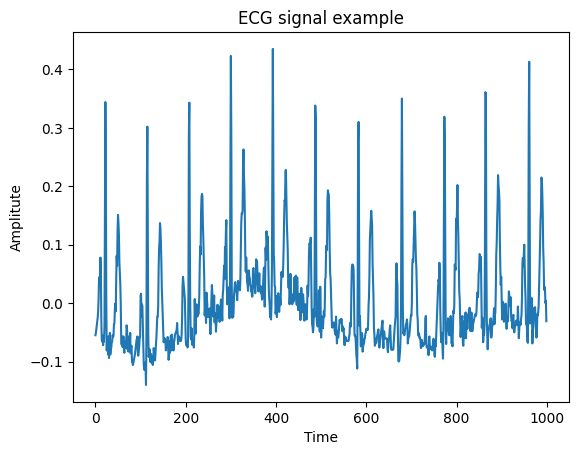

In [4]:
signal = X_train[0]
lead1 = signal[:,1] 
import matplotlib.pyplot as plt
plt.title("ECG signal example")
plt.plot(lead1)
plt.xlabel("Time")
plt.ylabel("Amplitute")
plt.show()

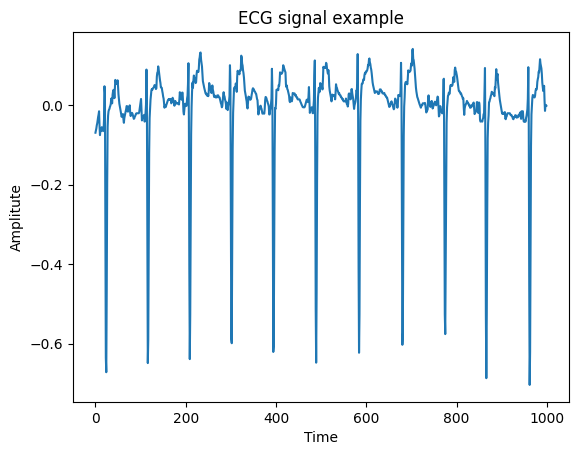

In [5]:
signal = X_train[0]
lead1 = signal[:,6] 
import matplotlib.pyplot as plt
plt.plot(lead1)
plt.title("ECG signal example")
plt.xlabel("Time")
plt.ylabel("Amplitute")
plt.show()

#### <b>CNN model </b>

In [6]:
model = keras.Sequential([
    keras.layers.Conv1D(filters=32,kernel_size=5,activation='relu',input_shape=(1000,12)),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(filters=64,kernel_size=5,activation='relu'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(filters=128,kernel_size=3,activation='relu'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(5, activation="sigmoid")
])

c:\Users\ytsub\Desktop\github\Know_Your_Health_MLModel\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.fit(
    X_train_filtered,
    y_train_binary,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 62s 112ms/step - accuracy: 0.6217 - loss: 0.3452 - val_accuracy: 0.6446 - val_loss: 0.3167
Epoch 2/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.7063 - loss: 0.2791 - val_accuracy: 0.6942 - val_loss: 0.2784
Epoch 3/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.7376 - loss: 0.2525 - val_accuracy: 0.7098 - val_loss: 0.2708
Epoch 4/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.7707 - loss: 0.2265 - val_accuracy: 0.7254 - val_loss: 0.2620
Epoch 5/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8038 - loss: 0.1997 - val_accuracy: 0.7187 - val_loss: 0.2741
Epoch 6/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8326 - loss: 0.1704 - val_accuracy: 0.7119 - val_loss: 0.2947
Epoch 7/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8641 - loss: 0.1465 - val_accuracy: 0.7080 - val_loss: 0.3144
Epoch 8/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8991 - loss: 0.1151 -

In [9]:
print("y_train dtype:", y_train.dtype)
print("y_train shape:", y_train.shape)
print("First few y_train samples:")
print(y_train[:5])

y_train dtype: object
y_train shape: (19601,)
First few y_train samples:
[list(['NORM']) list(['NORM']) list(['NORM']) list(['NORM'])
 list(['NORM'])]


In [10]:
import numpy as np
unique_labels = np.unique(np.concatenate(y_train))
print("Unique labels:", unique_labels)

Unique labels: ['CD' 'HYP' 'MI' 'NORM' 'STTC']


In [13]:
# Filter out samples with empty labels
valid_train_indices = [i for i, item in enumerate(y_train) if len(item) > 0]
valid_test_indices = [i for i, item in enumerate(y_test) if len(item) > 0]

X_train_filtered = X_train[valid_train_indices]
y_train_filtered = y_train[valid_train_indices]

X_test_filtered = X_test[valid_test_indices]
y_test_filtered = y_test[valid_test_indices]

print("Original X_train shape:", X_train.shape)
print("Filtered X_train shape:", X_train_filtered.shape)

# Now convert
y_train_labels = np.array([item[0] for item in y_train_filtered])
y_test_labels = np.array([item[0] for item in y_test_filtered])

# Define label mapping
label_to_idx = {'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}

# Create binary labels
y_train_binary = np.zeros((len(y_train_labels), 5))
y_test_binary = np.zeros((len(y_test_labels), 5))

for i, label in enumerate(y_train_labels):
    idx = label_to_idx[label]
    y_train_binary[i, idx] = 1

for i, label in enumerate(y_test_labels):
    idx = label_to_idx[label]
    y_test_binary[i, idx] = 1

print("y_train_binary shape:", y_train_binary.shape)
print("y_train_binary dtype:", y_train_binary.dtype)

Original X_train shape: (19601, 1000, 12)
Filtered X_train shape: (19230, 1000, 12)
y_train_binary shape: (19230, 5)
y_train_binary dtype: float64


In [17]:
model.evaluate(X_test_filtered, y_test_binary)

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6798 - loss: 1.1099


[1.109931468963623, 0.6797960996627808]